In [123]:
# Investigating the impact of vertical remapping algorithm on the gap flow test case

In [124]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors

In [125]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

In [126]:
rot = False
u = 10
gap = False

dycore = 'fv3'
res = 'C96'

lev_no = 'ztop30km_L56'

first_lot = True

if gap:
    prefix = ''
else:
    prefix='vortex_'

if first_lot:
    extra_name1 = f'{prefix}tau_1_2_kord4'
    extra_name2 = f'{prefix}tau_1_2_kord6'
    extra_name3 = f'{prefix}tau_1_2_kord7'
    
    plot_name1 = 'Monotonic PPM'
    plot_name2 = 'Vanilla PPM'
    plot_name3 = 'Hunyh monotonic PPM'
else:
    extra_name1 = f'{prefix}tau_1_2_kord9'
    extra_name2 = f'{prefix}tau_1_2_kord10'
    extra_name3 = f'{prefix}tau_1_2_kord11'
    
    plot_name1 = 'Monotonic cubic spline'
    plot_name2 = 'Selectively monotonic cubic spline'
    plot_name3 = 'Nonmonotonic cubic spline'

CAM_branch = 'CAM_6_4_070_17042025'

test_name_start = 'cam_6_4_070_horiz_mount_flow'

case1 = f'{test_name_start}_{dycore}_{res}_{lev_no}'
case2 = f'{test_name_start}_{dycore}_{res}_{lev_no}'
case3 = f'{test_name_start}_{dycore}_{res}_{lev_no}'


# Compare three files
if rot:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_with_rot_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_with_rot_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_with_rot_{extra_name3}'
else:
    nc_file1 = f'{case1}.cam.h0i.0001-01-01-00000_omega0_{extra_name1}'
    nc_file2 = f'{case2}.cam.h0i.0001-01-01-00000_omega0_{extra_name2}'
    nc_file3 = f'{case3}.cam.h0i.0001-01-01-00000_omega0_{extra_name3}'


nc_file1 = f'{nc_file1}.regrid.1x1.nc'
nc_file2 = f'{nc_file2}.regrid.1x1.nc'
nc_file3 = f'{nc_file3}.regrid.1x1.nc'

In [127]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case1 + '/run/' + nc_file1
run_path2 = run_base + case2 + '/run/' + nc_file2
run_path3 = run_base + case3 + '/run/' + nc_file3

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)
nc3 = Dataset(run_path3)

In [128]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

In [129]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat
if gap:
    lat_crop_up = 50.
    lat_cent_down = -50.
    lat_ticks = np.linspace(-40,40,5)
    lon_crop_left = 60.
    lon_crop_right = 250.
    lon_ticks = np.linspace(60, 225, 6)
else:
    lat_crop_up = 50.
    lat_cent_down = -10.
    lon_crop_left = 60.
    lon_crop_right = 225.
    lat_ticks = np.linspace(0,40,5)
    lon_ticks = np.linspace(60, 225, 6)

lon_inds = np.where((lon < lon_crop_right) & (lon > lon_crop_left))[0]
lat_inds = np.where((lat < lat_crop_up) & (lat > lat_cent_down))[0]

lat = lat[lat_inds]
lon = lon[lon_inds]

LON, LAT = np.meshgrid(lon, lat)

In [134]:
# Field to compare
field = 'T'

# Time index to compare at
t_idx = 80

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

# Choice of colormap
# Choice of colormap
if field == 'T':        
    cmap_choice = 'jet'
else:
    cmap_choice = 'seismic'
    #cmap_choice='jet'

In [135]:
# Interpolations:
field_vals1 = z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals2 = z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)
field_vals3 = z_interp(nc3['Z3'][t_idx, :, lat_inds, lon_inds], nc3[field][t_idx, :, lat_inds, lon_inds], lon, lat, z_val)

In [136]:
deg2rad = np.pi/180
T0 = 288

if field == 'U':
    # Normalised velocity perturbation:
        field_vals1 = (field_vals1 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals2 = (field_vals2 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
        field_vals3 = (field_vals3 - u*np.cos(LAT*deg2rad))/(u*np.cos(LAT*deg2rad))
else:
    # Temperature perturbation:
        field_vals1 = field_vals1 - T0
        field_vals2 = field_vals2 - T0
        field_vals3 = field_vals3 - T0

min value is -1.6768323615459053
max value is 5.104190629707432


Text(0.5, 0.01, 'Longitude (deg)')

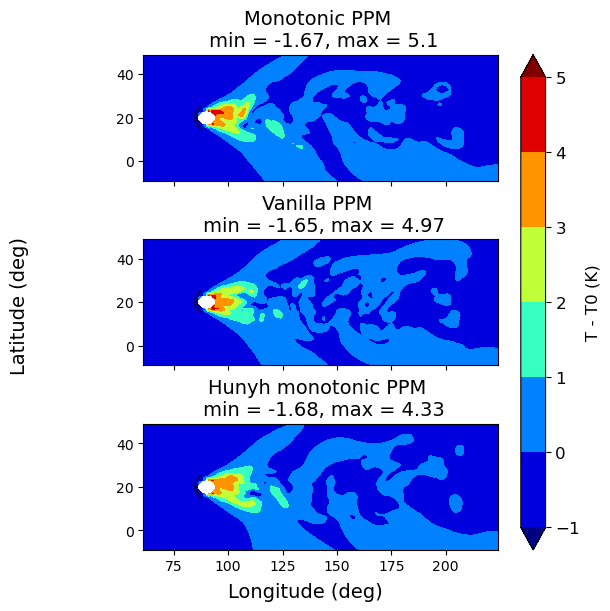

In [137]:
title_size=16
label_size=14
small_size=12

max1 = np.nanmax(field_vals1)
max2 = np.nanmax(field_vals2)
max3 = np.nanmax(field_vals3)

min1 = np.nanmin(field_vals1)
min2 = np.nanmin(field_vals2)
min3 = np.nanmin(field_vals3)

maxmax = max(max1, max2, max3)
minmin = min(min1, min2, min3)

print('min value is', minmin)
print('max value is', maxmax)

conts = np.linspace(minmin, maxmax, 21)

if gap:
    fig, axes = plt.subplots(1,3, sharey=True, figsize = (12,6), layout="constrained")
else:
    fig, axes = plt.subplots(3,1, sharex=True, figsize = (6,6), layout="constrained")
(ax1, ax2, ax3) = axes

if field == 'T':
    if rot:
        conts = np.linspace(-1, 5, 7)
        norm = colors.Normalize(vmin=-1, vmax=5)
        tick_range = np.linspace(-1, 5, 7)
    else:
        if gap:
            conts = np.linspace(-1, 5, 7)
            norm = colors.Normalize(vmin=-1, vmax=5)
            tick_range = np.linspace(-1, 5, 7)
        else:
            conts = np.linspace(-1, 2, 7)
            norm = colors.Normalize(vmin=-1, vmax=2)
            tick_range = np.linspace(-1, 2, 7)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Temperature perturbation'
    cb_label = 'T - T0 (K)'
else:
    if rot:
        conts = np.linspace(-2.0, 2.0, 9)
        tick_range = np.linspace(-2.0, 2.0, 9)
        norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)
    else:
        if gap:
            conts = np.linspace(-1.5, 1.0, 11)
            tick_range = np.linspace(-1.5, 1.0, 6)
            norm = colors.TwoSlopeNorm(vmin=-1.5, vcenter=0, vmax=1.0)
        else:
            conts = np.linspace(-1, 0.5, 13)
            tick_range = np.linspace(-1, 0.5, 7)
            norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=0.5)
    plot1 = ax1.contourf(LON, LAT, field_vals1, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot2 = ax2.contourf(LON, LAT, field_vals2, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    plot3 = ax3.contourf(LON, LAT, field_vals3, levels = conts, cmap=cmap_choice, norm=norm, extend = 'both')
    title = 'Normalised velocity perturbation'
    cb_label = '$(u(t) - u_0)/u_0$'

ax1.set_aspect('equal')
ax2.set_aspect('equal')
ax3.set_aspect('equal')

cb = plt.colorbar(plot3, ax=axes, ticks = tick_range, fraction=0.4)
cb.set_label(label=cb_label, size=small_size)
cb.ax.tick_params(labelsize=12)

ax1.set_title(f'{plot_name1} \n min = {np.round(min1,2)}, max = {np.round(max1,2)}', size=label_size)
ax2.set_title(f'{plot_name2} \n min = {np.round(min2,2)}, max = {np.round(max2,2)}', size=label_size)
ax3.set_title(f'{plot_name3} \n min = {np.round(min3,2)}, max = {np.round(max3,2)}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size)